# Sensitivity Analysis: Population & Demographics
This notebook analyses the demographic sensitivity of Nairobi to extreme heat. It processes large raster datasets (like HDX Meta High Resolution Population Density Maps) by:
1. Clipping them to the Nairobi boundary to reduce file size.
2. Resampling them to the common 50m analysis grid.
3. Normalising the indicators (0 = low sensitivity, 1 = high sensitivity).
4. Exporting the final maps for the web dashboard.


In [1]:
import os
import sys
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import gc

sys.path.append('../.')
from src.common_helper import *
from src.sensitivity_helper import *
from src.export_web_maps import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

LOC_RESULTS_DIR = os.path.join(RESULTS_DIR, "sensitivity")

Failed to read module file 'C:\Users\Surface\anaconda3\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Surface\anaconda3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen im

## 1. Setup Grid & Directories

In [2]:
# Create the standard 50m analysis grid for Nairobi
boundary = load_boundary()
grid = create_analysis_grid(boundary, resolution_m=50)

# Sensitivity raster inputs (HDX population, Meta RWI) live here
sensitivity_dir = os.path.join(DATA_DIR, '2_sensitivity')
os.makedirs(sensitivity_dir, exist_ok=True)
print(f"Sensitivity data dir: {sensitivity_dir}")

  Grid created: 631 x 982 cells (50 m resolution)
Sensitivity data dir: c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\data\geospatial\2_sensitivity


## 2. Run Analysis & Export to Web
Once the rasters are clipped, uncomment the code below to resample them to the analysis grid, normalise them, and export them.


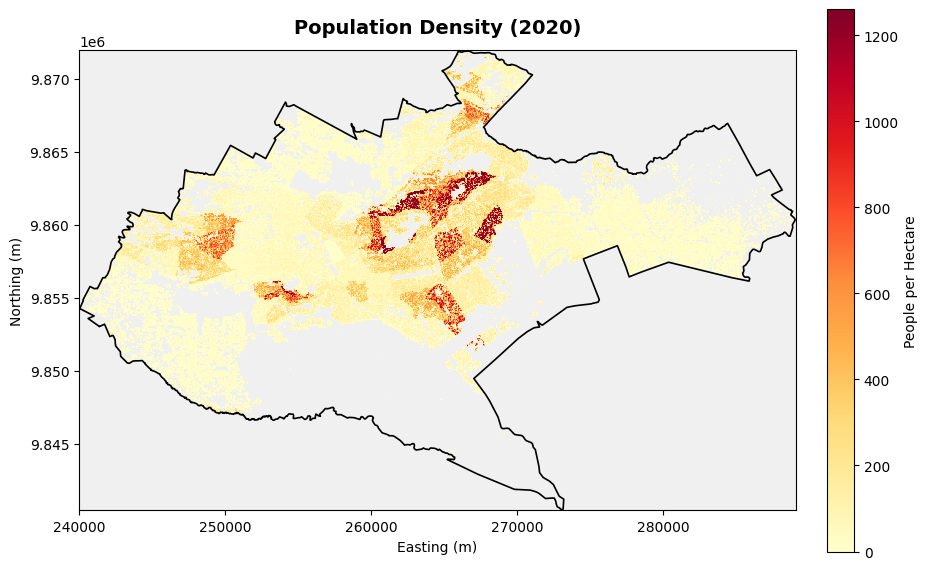

Exported 'sensitivity_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Exported raw data for 'sensitivity_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps\sensitivity_population_raw.png


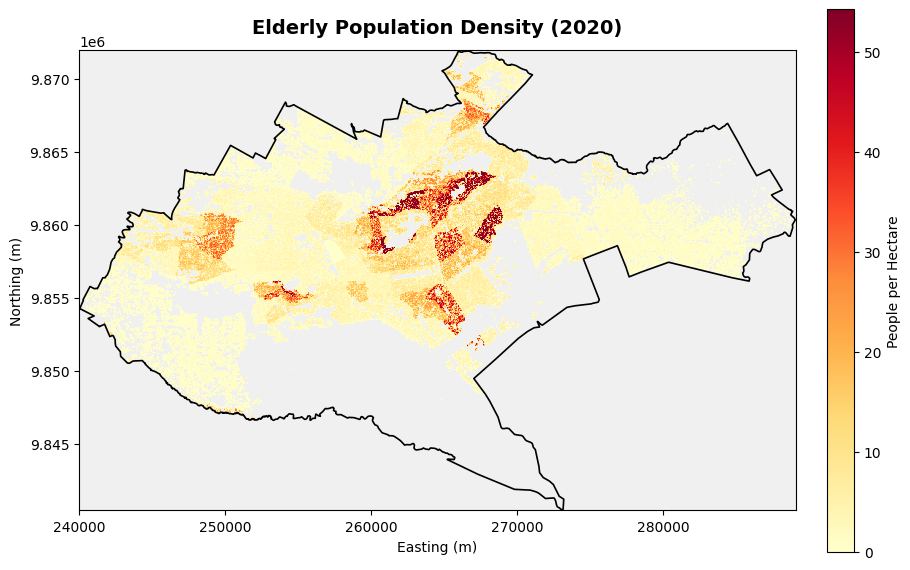

Exported 'sensitivity_elderly_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Exported raw data for 'sensitivity_elderly_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps\sensitivity_elderly_population_raw.png


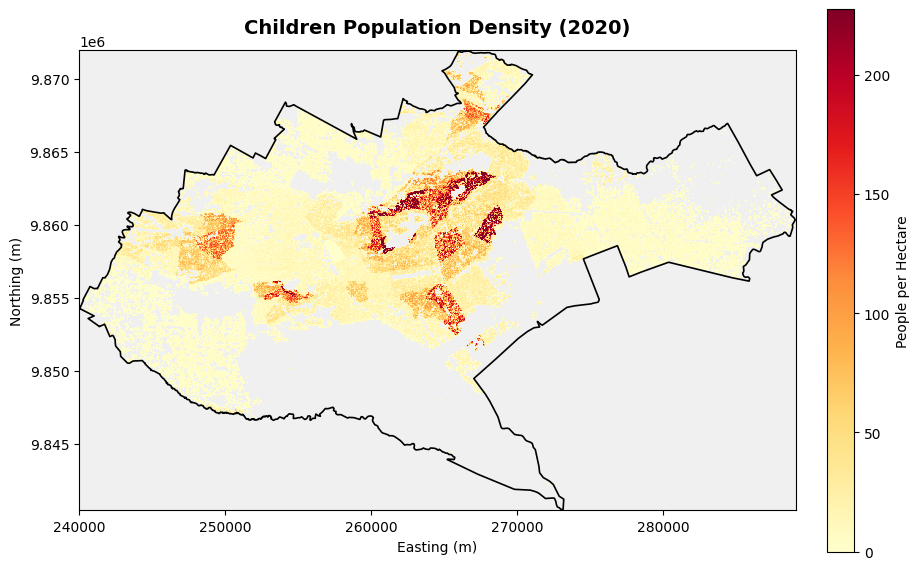

Exported 'sensitivity_children_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Exported raw data for 'sensitivity_children_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps\sensitivity_children_population_raw.png


In [3]:
# Population sensitivity layers (general / elderly / children)
WEBAPP_MAPS = os.path.join(PROJECT_ROOT, 'webapp', 'public', 'maps')
pixel_area_ha = (grid['resolution'] ** 2) / 10000.0
seq_cmap = plt.get_cmap('YlOrRd')   # classic sequential scale (yellow -> red)
pop_layers = [
    ('nairobi_general_pop_2020.tif',  'sensitivity_population',          'Population Density (2020)'),
    ('nairobi_elderly_pop_2020.tif',  'sensitivity_elderly_population',  'Elderly Population Density (2020)'),
    ('nairobi_children_pop_2020.tif', 'sensitivity_children_population', 'Children Population Density (2020)'),
]

for fname, web_name, title in pop_layers:
    pop_count = resample_to_grid(os.path.join(sensitivity_dir, fname), grid)
    if pop_count is None:
        print(f"  Skipping {web_name}: {fname} not found")
        continue

    pop_density_ha = pop_count / pixel_area_ha
    valid = pop_density_ha[np.isfinite(pop_density_ha)]
    vmax_val = np.percentile(valid, 99) if len(valid) else 1

    ax = plot_layer(pop_density_ha, grid, title,
                    cmap=seq_cmap,
                    cbar_label='People per Hectare', vmin=0, vmax=vmax_val)
    plt.show()
    plt.close(ax.figure)

    # Normalised 0-1, exported straight to the webapp's served maps folder
    pop_sensitivity = normalize_layer(pop_count)
    export_raster_for_web(pop_sensitivity, grid, web_name, cmap=seq_cmap, output_dir=WEBAPP_MAPS)
    export_raw_for_web(pop_sensitivity, web_name, output_dir=WEBAPP_MAPS)

    del pop_count, pop_density_ha, pop_sensitivity, valid
    gc.collect()

## 3. Income & Demographic Evolution
Here we process the Meta Relative Wealth Index and the WorldPop demographic evolution.

In [4]:
import ee
import geemap
import pandas as pd
import geopandas as gpd
from scipy.interpolate import griddata
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

def align_raster(tif_path, grid):
    with rasterio.open(tif_path) as src:
        dst_array = np.empty((grid["nrows"], grid["ncols"]), dtype=np.float32)
        dst_array[:] = np.nan
        reproject(
            source=rasterio.band(src, 1),
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=grid["transform"],
            dst_crs=grid["crs"],
            resampling=Resampling.nearest
        )
        dst_array[~grid["mask"]] = np.nan
        return dst_array

try:
    ee.Initialize(project="ee-nairobi-heatmap")
except Exception as e:
    print("Earth engine auth needed:", e)

print("1. Downloading WorldPop Growth (2010 to 2020)...")
boundary_ee = geemap.geopandas_to_ee(boundary)
pop_2010 = ee.ImageCollection("WorldPop/GP/100m/pop").filterBounds(boundary_ee).filterDate("2010-01-01", "2010-12-31").mean()
pop_2020 = ee.ImageCollection("WorldPop/GP/100m/pop").filterBounds(boundary_ee).filterDate("2020-01-01", "2020-12-31").mean()
pop_growth = pop_2020.subtract(pop_2010).clipToCollection(boundary_ee)

growth_tif = os.path.join(LOC_RESULTS_DIR, "pop_growth.tif")
geemap.ee_export_image(pop_growth, filename=growth_tif, scale=100, region=boundary_ee.geometry())

print("Calculating 2030 Prediction...")
pop_2030_pred = pop_2020.add(pop_growth).clipToCollection(boundary_ee)
pred_tif = os.path.join(LOC_RESULTS_DIR, "pop_2030_pred.tif")
geemap.ee_export_image(pop_2030_pred, filename=pred_tif, scale=100, region=boundary_ee.geometry())


1. Downloading WorldPop Growth (2010 to 2020)...
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\sensitivity\pop_growth.tif
Calculating 2030 Prediction...
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\sensitivity\pop_2030_pred.tif


In [5]:
print("2. Processing Meta Relative Wealth Index...")
# Load RWI
rwi_df = pd.read_csv(os.path.join(sensitivity_dir, "ken_relative_wealth_index.csv"))
rwi_gdf = gpd.GeoDataFrame(rwi_df, geometry=gpd.points_from_xy(rwi_df.longitude, rwi_df.latitude), crs="EPSG:4326")

# Clip to Nairobi
rwi_nairobi = gpd.clip(rwi_gdf, boundary)

# Rasterize / Interpolate to grid
rwi_utm = rwi_nairobi.to_crs(grid["crs"])
minx, miny, maxx, maxy = grid["bounds"]
grid_x, grid_y = np.mgrid[minx:maxx:complex(0, grid["ncols"]), maxy:miny:complex(0, grid["nrows"])]
points = np.array([rwi_utm.geometry.x, rwi_utm.geometry.y]).T
values = rwi_utm["rwi"].values

# IDW or nearest interpolation
grid_rwi = griddata(points, values, (grid_x, grid_y), method="linear")
grid_rwi = np.nan_to_num(grid_rwi, nan=np.nanmean(values))
grid_rwi = grid_rwi.T
grid_rwi[~grid["mask"]] = np.nan


2. Processing Meta Relative Wealth Index...


In [6]:
print("3. Aligning rasters and Exporting Maps to Webapp...")
from src.common_helper import COMPOSITE_CMAP
WEBAPP_MAPS = os.path.join(PROJECT_ROOT, 'webapp', 'public', 'maps')
seq_cmap = plt.get_cmap('YlOrRd')      # classic sequential for population
div_cmap = COMPOSITE_CMAP.reversed()   # diverging for wealth (RWI centred on 0)

growth_array = align_raster(growth_tif, grid)
pred_array = align_raster(pred_tif, grid)

# pop_2030 is the TOTAL predicted population (2020 + growth). Normalise it like
# the 2020 population map so it is comparable on the dashboard (not dim).
export_raster_for_web(normalize_layer(growth_array), grid, "sensitivity_pop_evolution", cmap=seq_cmap, output_dir=WEBAPP_MAPS)
export_raster_for_web(normalize_layer(pred_array),   grid, "sensitivity_pop_2030",      cmap=seq_cmap, output_dir=WEBAPP_MAPS)

# RWI: mask to inhabited pixels for the dashboard (it is interpolated everywhere,
# so empty park/outskirts are extrapolated junk that shifts the colour scale).
_pg = resample_to_grid(os.path.join(sensitivity_dir, 'nairobi_general_pop_2020.tif'), grid)
rwi_web = grid_rwi.copy()
if _pg is not None:
    rwi_web[~((_pg > 0) & grid['mask'])] = np.nan
export_raster_for_web(rwi_web, grid, "sensitivity_wealth", cmap=div_cmap, vmin=-1, vmax=2, output_dir=WEBAPP_MAPS)

# Save the numeric wealth grid for the statistics notebook (reuse, no recompute)
export_grid_data(grid_rwi, grid, "wealth")
print("Done! Dashboard maps written to webapp/public/maps + wealth grid saved for stats.")

3. Aligning rasters and Exporting Maps to Webapp...
Exported 'sensitivity_pop_evolution' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Exported 'sensitivity_pop_2030' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Exported 'sensitivity_wealth' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Saved grid data 'wealth' -> c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\data\wealth.tif
Done! Dashboard maps written to webapp/public/maps + wealth grid saved for stats.
